In [1]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'format': 'netcdf',
        'variable': [
            '10m_u_component_of_wind', '10m_v_component_of_wind', 'mean_sea_level_pressure',
            'total_precipitation',
        ],
        'year': '2020',
        'month': '03',
        'day': [
            '9', '10', '11', '12',
            '13', '14',
        ],
        'time': [
            '00:00', '01:00', '02:00',
            '03:00', '04:00', '05:00',
            '06:00', '07:00', '08:00',
            '09:00', '10:00', '11:00',
            '12:00', '13:00', '14:00',
            '15:00', '16:00', '17:00',
            '18:00', '19:00', '20:00',
            '21:00', '22:00', '23:00',
        ],
        'area': [
            90, -60, 30,
            50,
        ],
    },
    'case2020_singlev_update.nc')

2024-07-16 12:14:31,079 INFO Welcome to the CDS
2024-07-16 12:14:31,081 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2024-07-16 12:14:31,249 INFO Request is queued
2024-07-16 12:14:32,292 INFO Request is running
2024-07-16 12:15:20,864 INFO Request is completed
2024-07-16 12:15:20,868 INFO Downloading https://download-0017.copernicus-climate.eu/cache-compute-0017/cache/data7/adaptor.mars.internal-1721132104.2388878-1134-6-4e574176-4d03-474c-9185-b377ebdd6e20.nc to case2020_singlev_update.nc (116.8M)
2024-07-16 12:15:32,861 INFO Download rate 9.7M/s  


Result(content_length=122440888,content_type=application/x-netcdf,location=https://download-0017.copernicus-climate.eu/cache-compute-0017/cache/data7/adaptor.mars.internal-1721132104.2388878-1134-6-4e574176-4d03-474c-9185-b377ebdd6e20.nc)

In [2]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'format': 'netcdf',
        'product_type': 'monthly_averaged_reanalysis',
        'variable': 'mean_sea_level_pressure',
        'year': [
            '1990', '1991', '1992',
            '1993', '1994', '1995',
            '1996', '1997', '1998',
            '1999', '2000', '2001',
            '2002', '2003', '2004',
            '2005', '2006', '2007',
            '2008', '2009', '2010',
            '2011',
            '2012', '2013', '2014',
            '2015', '2016', '2017',
            '2018', '2019', '2020',

        ],
        'month': '03',
        'time': '00:00',
        'area': [
            80, -45, 30,
            45,
        ],
    },
    'mar_mslp.nc')

2024-07-16 12:16:54,965 INFO Welcome to the CDS
2024-07-16 12:16:54,967 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels-monthly-means
2024-07-16 12:16:55,071 INFO Request is queued
2024-07-16 12:16:56,115 INFO Request is running
2024-07-16 12:17:27,777 INFO Request is completed
2024-07-16 12:17:27,778 INFO Downloading https://download-0011-clone.copernicus-climate.eu/cache-compute-0011/cache/data1/adaptor.mars.internal-1721132238.101975-26455-20-dac38c85-33c3-42df-acdc-eb28c1bf9002.nc to mar_mslp.nc (4.3M)
2024-07-16 12:17:28,287 INFO Download rate 8.5M/s   


Result(content_length=4502288,content_type=application/x-netcdf,location=https://download-0011-clone.copernicus-climate.eu/cache-compute-0011/cache/data1/adaptor.mars.internal-1721132238.101975-26455-20-dac38c85-33c3-42df-acdc-eb28c1bf9002.nc)

In [20]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

In [21]:
eradata = xr.open_dataset('case2020_singlev_update.nc')
#eradata = eradata.sel(time=slice('2020-03-11T00:00:00','2020-03-13T23:00:00'))

In [22]:
lons = eradata['longitude']
lats = eradata['latitude']

lons, lats = np.meshgrid(lons, lats)

uwnd = eradata['u10']
vwnd = eradata['v10']
msl = eradata['msl'] / 100
prec = eradata['tp'] * 1000

In [23]:
import cartopy.geodesic as cgeodesic
def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('ID'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon_vor'].iloc[i], group['lat_vor'].iloc[i]],
                [group['lon_vor'].iloc[i+1], group['lat_vor'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)  # Calculate speed
            bearing = out[0, 1]  # Azimuth bearing

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing

In [24]:
trx = pd.DataFrame()
file_path = f'Track/ERA5_VOR850_1hr_oct-mar20192020_NORTHSEA_minwindspeed25_longlive.csv'
trx_data = pd.read_csv(file_path)
trx = pd.concat([trx, trx_data], ignore_index=True) 
trx['lon_vor'] = ((trx['lon_vor'] + 180) % 360) - 180
trx = calc_speed_dir(trx, 1)
trx['bearing'] = trx['bearing'].apply(adjust_bearing)
trx.head()

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,var_prec,ID,start_time,median_time,name,season,duration,distance,speed,bearing
0,0,2019-10-12 22:00:00,-8.263824,47.168446,3.801767,353.3005,47.10539,1003.502,351.0000,44.54331,...,14.98366,1652,2019-10-12 22:00:00,NaN,NaN,2019-2020,7 days 09:00:00,47.025859,13.062739,31.286109
1,1,2019-10-12 23:00:00,-7.939514,47.529461,3.972015,353.6849,47.64709,1002.719,351.2812,44.54331,...,14.59693,1652,2019-10-12 22:00:00,NaN,NaN,2019-2020,7 days 09:00:00,51.280899,14.244694,48.033504
2,2,2019-10-13 00:00:00,-7.430176,47.836754,4.084448,351.3453,49.43111,1001.120,350.7188,43.41919,...,15.23912,1652,2019-10-12 22:00:00,NaN,NaN,2019-2020,7 days 09:00:00,51.184422,14.217895,56.433748
3,3,2019-10-13 01:00:00,-6.857666,48.089851,4.247403,354.4774,48.49998,1001.290,351.0000,43.41919,...,15.61092,1652,2019-10-12 22:00:00,NaN,NaN,2019-2020,7 days 09:00:00,52.768922,14.658034,54.744868
4,4,2019-10-13 02:00:00,-6.276154,48.362312,4.526929,354.7919,48.82745,1000.489,351.2812,43.41919,...,14.38624,1652,2019-10-12 22:00:00,NaN,NaN,2019-2020,7 days 09:00:00,60.020741,16.672428,54.209778


In [25]:
storm_id_sel = [26427, 26967]
trx_sel = trx[trx['ID'].isin(storm_id_sel)]
trx_sel

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,var_prec,ID,start_time,median_time,name,season,duration,distance,speed,bearing
1464,1464,2020-03-08 05:00:00,-48.629974,47.908566,11.815530,309.84740,46.76947,987.7206,315.56250,45.38640,...,19.22174,26427,2020-03-08 05:00:00,NaN,NaN,2019-2020,13 days 00:00:00,89.275876,24.798854,62.414730
1465,1465,2020-03-08 06:00:00,-47.563934,48.275440,11.817150,NaN,NaN,988.2233,315.56250,45.38640,...,18.09523,26427,2020-03-08 05:00:00,NaN,NaN,2019-2020,13 days 00:00:00,86.792434,24.109009,61.341510
1466,1466,2020-03-08 07:00:00,-46.530396,48.645145,11.863630,310.78670,47.60066,985.6062,318.09380,47.35361,...,18.01049,26427,2020-03-08 05:00:00,NaN,NaN,2019-2020,13 days 00:00:00,61.995733,17.221037,54.783610
1467,1467,2020-03-08 08:00:00,-45.838684,48.964561,11.883770,311.60110,48.15053,984.7227,318.65620,47.91567,...,17.73524,26427,2020-03-08 05:00:00,NaN,NaN,2019-2020,13 days 00:00:00,52.486061,14.579461,50.330865
1468,1468,2020-03-08 09:00:00,-45.283600,49.264500,11.852160,312.43190,48.68658,983.7606,317.25000,45.10537,...,17.82754,26427,2020-03-08 05:00:00,NaN,NaN,2019-2020,13 days 00:00:00,97.953486,27.209302,68.297778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1862,1862,2020-03-14 23:00:00,83.932114,68.254967,4.596950,NaN,NaN,980.7238,79.03125,68.99293,...,12.90145,26967,2020-03-11 10:00:00,NaN,NaN,2019-2020,3 days 17:00:00,30.478616,8.466282,136.063989
1863,1863,2020-03-15 00:00:00,84.439041,68.057411,4.522360,NaN,NaN,981.1368,79.03125,68.71190,...,12.69702,26967,2020-03-11 10:00:00,NaN,NaN,2019-2020,3 days 17:00:00,36.445803,10.123834,150.139531
1864,1864,2020-03-15 01:00:00,84.868736,67.773460,4.431969,92.81520,70.43100,977.4707,79.87500,68.99293,...,12.12522,26967,2020-03-11 10:00:00,NaN,NaN,2019-2020,3 days 17:00:00,43.593485,12.109301,157.862909
1865,1865,2020-03-15 02:00:00,85.251808,67.410950,4.323477,89.33022,69.50978,979.2287,80.15625,68.99293,...,11.55193,26967,2020-03-11 10:00:00,NaN,NaN,2019-2020,3 days 17:00:00,50.160775,13.933549,158.009250


/tmp/ipykernel_639/668408852.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(storm_id_sel))


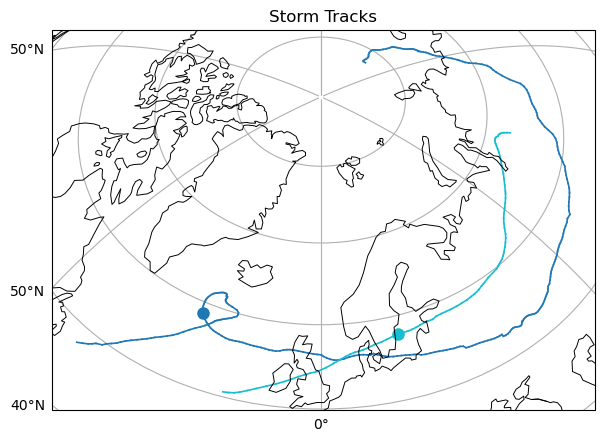

In [28]:
datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': mapcrs})
ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

cmap = cm.get_cmap('tab10', len(storm_id_sel))

# Group the selected DataFrame by 'ID' and plot each group with a different color
for idx, (name, group) in enumerate(trx_sel.groupby('ID')):
    color = cmap(idx)  # Get a unique color for each storm track
    points = group[['lon_vor', 'lat_vor']].values
    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        ax.plot(line[:, 0], line[:, 1], color=color, linewidth=1.2, transform=datacrs)
    
    # Find the point with the minimum var_mslp value
    min_mslp_idx = group['var_vor'].idxmax()
    min_mslp_point = group.loc[min_mslp_idx, ['lon_vor', 'lat_vor']]
    
    # Plot the point with the minimum var_mslp value
    ax.plot(min_mslp_point['lon_vor'], min_mslp_point['lat_vor'], 'o', color=color, markersize=8, transform=datacrs)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Storm Tracks')

plt.show()


/tmp/ipykernel_729/539248295.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('PiYG', len(storm_id_sel))


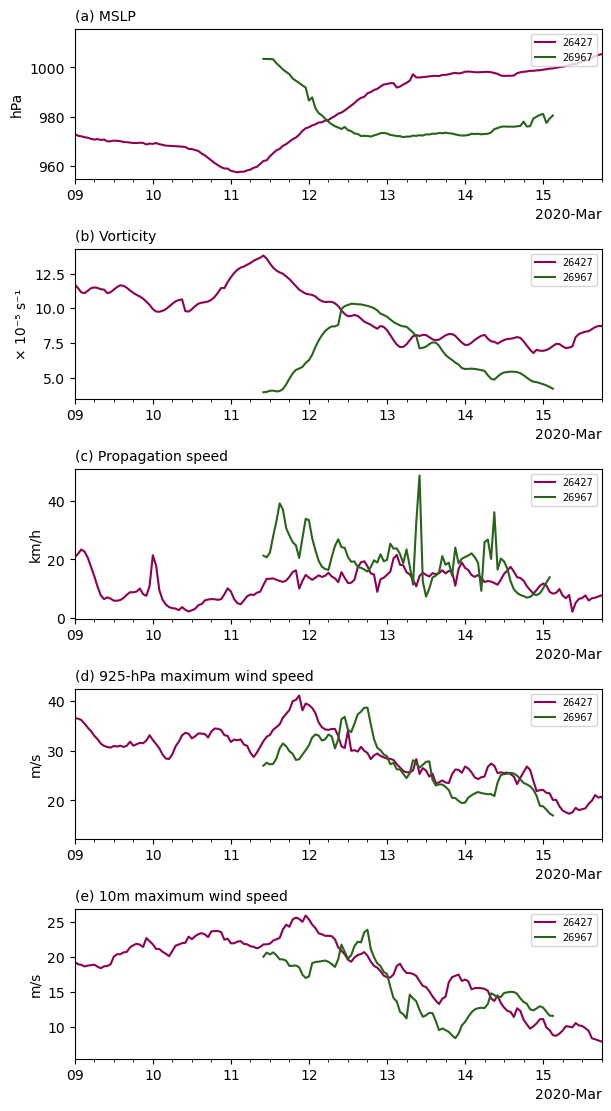

In [26]:
import matplotlib.dates as mdates
import matplotlib.units as munits

formats = ['%y',          # ticks are mostly years
           '%b',     # ticks are mostly months
           '%d',     # ticks are mostly days
           '%HZ',  # hrs
           '%H:%M',  # min
           '%S.%f', ]  # secs
zero_formats = [''] + formats[:-1]
zero_formats[3] = '%HZ\n%d %b %Y'
waktuini = (np.datetime64('2020-03-09 00:00:00'), np.datetime64('2020-03-15 18:00:00'))


fig, axs = plt.subplots(figsize=(6., 11.), nrows=5, ncols=1, constrained_layout=True)
converter = mdates.ConciseDateConverter(formats=formats, zero_formats=zero_formats, show_offset=0)
locator = mdates.AutoDateLocator(minticks=6, maxticks=24)
formatter = mdates.ConciseDateFormatter(locator)

# Set x-axis locator and formatter for all subplots
for ax in axs:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))
    ax.set_xlim(waktuini)

# Plot data for each variable
variables = ['var_mslp', 'var_vor', 'speed', 'var_wind', 'var_prec']  # Assuming these are your variables
titles = ['(a) MSLP', '(b) Vorticity', '(c) Propagation speed', '(d) 925-hPa maximum wind speed', '(e) 10m maximum wind speed']
ylabels = ['hPa', '× 10⁻⁵ s⁻¹', 'km/h', 'm/s', 'm/s']
cmap = cm.get_cmap('PiYG', len(storm_id_sel))
for idx, (var, title, ylabel) in enumerate(zip(variables, titles, ylabels)):
    for storm_idx, (name, group) in enumerate(trx_sel.groupby('ID')):
        if var in group.columns:
            color = cmap(storm_idx)
            axs[idx].plot(group['date'], group[var], label=f'{name}', color=color)
        else:
            print(f"Variable {var} not found in group columns")
            
    axs[idx].set_ylabel(ylabel)
    axs[idx].set_title(title, loc='left', fontsize=10)
    axs[idx].legend(frameon=True, fancybox=True, fontsize=7, loc='upper right')

plt.show()


/tmp/ipykernel_729/1746279306.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_sel['date'] = pd.to_datetime(trx_sel['date'])
/tmp/ipykernel_729/1746279306.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('PiYG', len(storm_id_sel))
Locator attempting to generate 1457 ticks ([19358.0, ..., 19722.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1457 ticks ([19358.0, ..., 19722.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 1457 ticks ([19358.0, ..., 19722.0]), which exceeds Locator.MAXTICKS (1000)

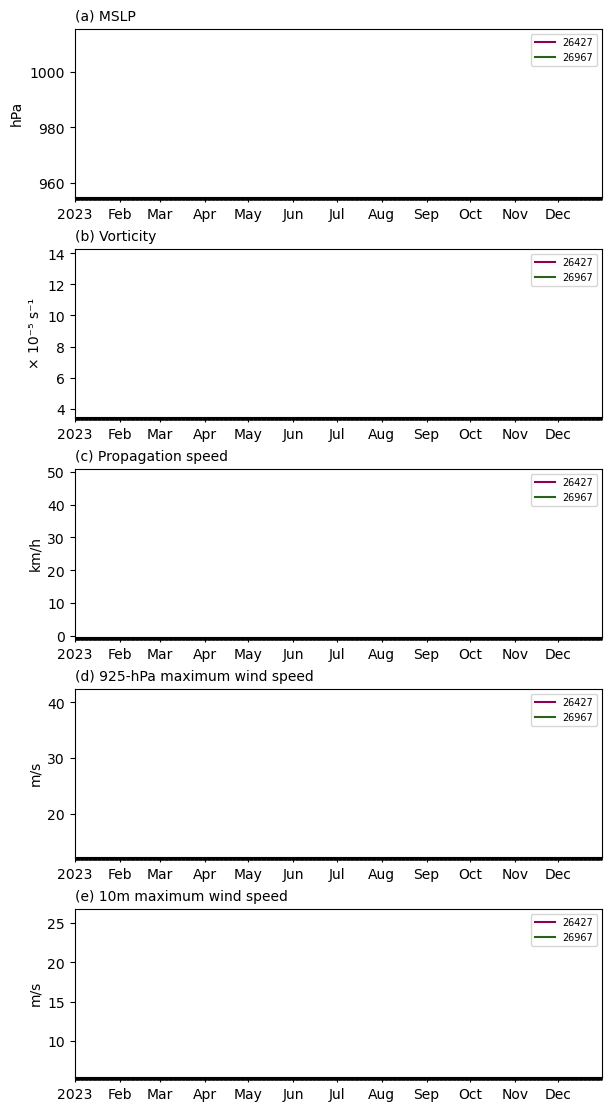

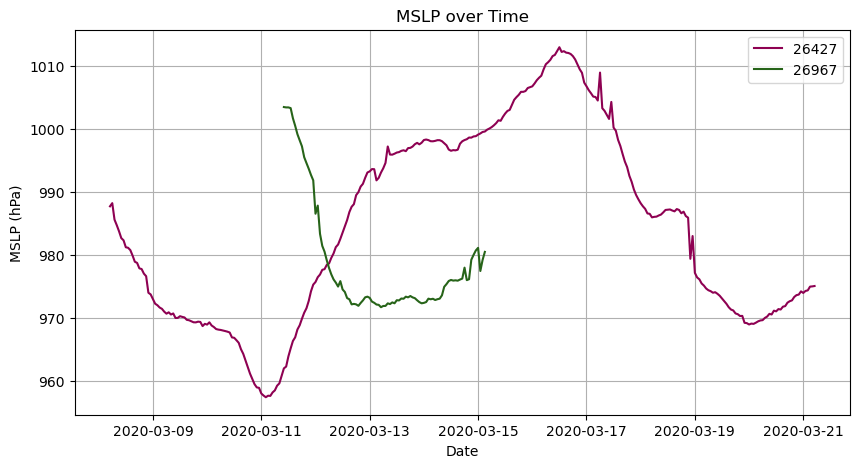

In [24]:
import datetime
start_datetime = datetime.datetime(2023, 1, 1)
end_datetime = datetime.datetime(2023, 12, 31)
waktuini = [start_datetime, end_datetime]

trx_sel['date'] = pd.to_datetime(trx_sel['date'])


fig, axs = plt.subplots(figsize=(6., 11.), nrows=5, ncols=1, constrained_layout=True)
formats = {'year': '%Y', 'month': '%b', 'day': '%d', 'hour': '%H'}
zero_formats = {'year': '%Y', 'month': '%b', 'day': '%d', 'hour': '%H'}
converter = mdates.ConciseDateConverter(formats=formats, zero_formats=zero_formats, show_offset=False)
locator = mdates.AutoDateLocator(minticks=6, maxticks=24)
formatter = mdates.ConciseDateFormatter(locator)

# Set x-axis locator and formatter for all subplots
for ax in axs:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=6))
    ax.set_xlim(waktuini)

# Plot data for each variable
variables = ['var_mslp', 'var_vor', 'speed', 'var_wind', 'var_prec']  # Assuming these are your variables
titles = ['(a) MSLP', '(b) Vorticity', '(c) Propagation speed', '(d) 925-hPa maximum wind speed', '(e) 10m maximum wind speed']
ylabels = ['hPa', '× 10⁻⁵ s⁻¹', 'km/h', 'm/s', 'm/s']
cmap = cm.get_cmap('PiYG', len(storm_id_sel))

# Plot individual series for debugging
grouped = trx_sel.groupby('ID')
#for name, group in grouped:
#    print(f"Group: {name}")
#    print(group.head())

# Check if dates are within waktuini range
for idx, (var, title, ylabel) in enumerate(zip(variables, titles, ylabels)):
    for storm_idx, (name, group) in enumerate(grouped):
        #print(f"Plotting variable '{var}' for storm ID '{name}'")
        if var in group.columns:
            #print(f"Data for {name} - {var}:\n{group[['date', var]].head()}")
            color = cmap(storm_idx)
            axs[idx].plot(group['date'], group[var], label=f'{name}', color=color)
        else:
            print(f"Variable {var} not found in group columns")
            
    axs[idx].set_ylabel(ylabel)
    axs[idx].set_title(title, loc='left', fontsize=10)
    axs[idx].legend(frameon=True, fancybox=True, fontsize=7, loc='upper right')

# Print axes limits for debugging
#for ax in axs:
#    print(f"xlim: {ax.get_xlim()}")
#    print(f"ylim: {ax.get_ylim()}")

plt.show()

# Plot a simple example outside the loop
plt.figure(figsize=(10, 5))
for storm_idx, (name, group) in enumerate(grouped):
    plt.plot(group['date'], group['var_mslp'], label=f'{name}', color=cmap(storm_idx))
plt.xlabel('Date')
plt.ylabel('MSLP (hPa)')
plt.title('MSLP over Time')
plt.legend()
plt.grid(True)
plt.show()


In [9]:
# Plot a simple example outside the loop
plt.figure(figsize=(10., 3))
for storm_idx, (name, group) in enumerate(grouped):
    plt.plot(group['date'], group['var_vor'], label=f'{name}', color=cmap(storm_idx))
plt.xlabel('Date')
plt.ylabel('Vorticity (× 10⁻⁵ s⁻¹)')
plt.title('Vorticity over Time')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'grouped' is not defined

<Figure size 1000x300 with 0 Axes>

In [15]:
dec_mslp = xr.open_dataset('mar_mslp.nc')
msl_ = dec_mslp['msl'] / 100
msl_clim = msl_.mean(dim='time')

msl_anom = msl - msl_clim
msl_anom.max()

<xarray.DataArray 'msl' ()> Size: 8B
array(20.31898164)

In [16]:
lonsi = msl_anom['longitude']
latsi = msl_anom['latitude']

msl_anom_all = msl_anom.mean(dim='time')
uwnd_all = uwnd.mean(dim='time')
vwnd_all = vwnd.mean(dim='time')

In [17]:
prec_sum = prec.sum(dim='time')
prec_sum.max()

<xarray.DataArray 'tp' ()> Size: 8B
array(82.0473478)

/tmp/ipykernel_729/1149350171.py:31: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  for collection in cs.collections:
/tmp/ipykernel_729/1149350171.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('PiYG', len(storm_id_sel))


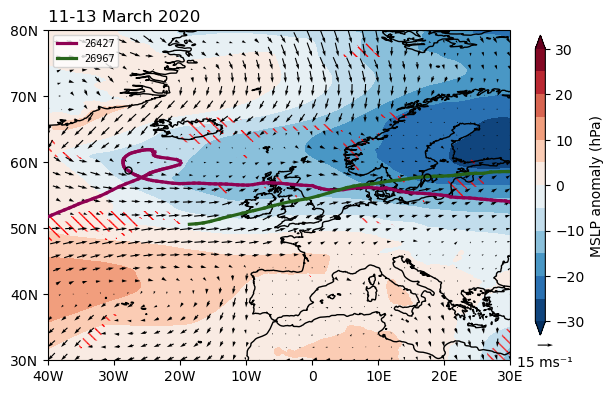

In [22]:
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-40, -30, -20, -10, 0, 10, 20, 30]
lats_tick = [80, 70, 60, 50, 40, 30]

fig, ax = plt.subplots(1, 1, sharey=True, sharex=True, figsize=(5., 5.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=1)  

colorvim_levels = np.arange(-30, 35, 5)
contf = ax.contourf(lonsi, latsi, msl_anom_all, levels=colorvim_levels, cmap=plt.cm.RdBu_r, extend='both', transform=datacrs, zorder=0)

skip=(slice(None,None,8),slice(None,None,8))
wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd_all[skip], vwnd_all[skip], 
                              pivot='tip', transform=datacrs, zorder=5)

ax.quiverkey(wind_vec_plot, 1.12, 0.2, 15, '15 ms⁻¹', labelpos='S', zorder=24,
                   coordinates='figure')

col_map = np.arange(20, 100, 10)

levels = np.linspace(20, np.max(prec_sum), num=50)
prec_sum_masked = np.ma.masked_less_equal(prec_sum, 20)
cs = ax.contourf(lons, lats, prec_sum_masked, levels=levels, hatches=['\\\\\\'], vmin=25, extend='max', colors='None',
                 transform=datacrs)
for collection in cs.collections:
    collection.set_edgecolor('red')
    collection.set_linewidth(0)
    
cmap = cm.get_cmap('PiYG', len(storm_id_sel))
lines = []
labels = []

for idx, (name, group) in enumerate(trx_sel.groupby('ID')):
    color = cmap(idx)  # Get a unique color for each storm track
    points = group[['lon_vor', 'lat_vor']].values
    for i in range(len(points) - 1):
        line = np.array([points[i], points[i + 1]])
        line_obj, = ax.plot(line[:, 0], line[:, 1], color=color, linewidth=2.3, transform=datacrs, zorder=20)
        
    lines.append(line_obj)
    labels.append(f'{name}')

    min_mslp_idx = group['var_vor'].idxmax()
    min_mslp_point = group.loc[min_mslp_idx, ['lon_vor', 'lat_vor']]
    
    # Plot the point with the minimum var_mslp value
    ax.plot(min_mslp_point['lon_vor'], min_mslp_point['lat_vor'], 'o', color=color, markersize=5, markeredgecolor='black',
            markerfacecolor='None', transform=datacrs, zorder=21)

ax.set_title('11-13 March 2020', weight='normal', loc='left')
ax.legend(lines, labels, loc='upper left', fontsize=7)

fig.subplots_adjust(bottom=0.1, right=1.05, top=0.9, wspace=0.12, hspace=0.25)
cax = fig.add_axes([1.1, 0.22, 0.02, 0.6])
#dax = fig.add_axes([1.3, 0.22, 0.02, 0.6])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=20)
cb.set_label('MSLP anomaly (hPa)')

#pr = plt.colorbar(contf_prec, cax=dax, orientation='vertical', aspect=20)
#pr.set_label('Total precipitation (mm)')

#plt.savefig('fig_anom_msl.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
sel_trx = trx_sel[(trx_sel['date'] >= '2020-03-09 00:00:00') & (trx_sel['date'] <= '2020-03-14 23:00:00')]
time_sel_trx = sel_trx['date'].nunique

/tmp/ipykernel_639/4101986611.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timesel = pd.date_range(start='2020-03-09 00:00:00', end='2020-03-14 23:00:00', freq='H')


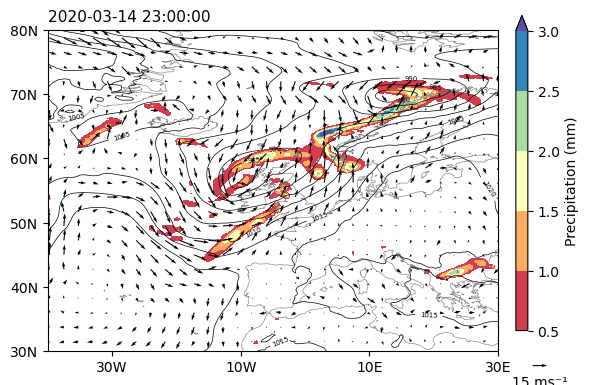

In [31]:
from matplotlib.animation import FuncAnimation

mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
datacrs = ccrs.PlateCarree()
boundary = [-40, 30, 80, 30]
lons_tick = [-30, -10, 10, 30] 
lats_tick = [80, 70, 60, 50, 40, 30]
colorvim_levels = np.arange(0.5, 3.5, 0.5)
cbar = np.arange(960, 1025, 5) 

fig, ax = plt.subplots(1,1,sharey=True, sharex=True, figsize=(6., 7.), subplot_kw={'projection': datacrs})
ax.set_extent(boundary, crs=datacrs) 
ax.set_xticks(lons_tick, crs=datacrs)  
ax.set_yticks(lats_tick, crs=datacrs)  
ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
ax.coastlines(linewidth=0.85, color='grey')  
contf = ax.contourf(lons, lats, prec.sel(time=timesel[0]), levels=colorvim_levels, vmin=0.5, cmap=plt.cm.Spectral, 
                    extend='max', transform=datacrs, zorder=0)

fig.subplots_adjust(left=0.1, bottom=0.1, right=0.85, top=0.9, wspace=0.12, hspace=0.25)
cax = fig.add_axes([0.88, 0.3, 0.02, 0.45])
cb = plt.colorbar(contf, cax=cax, orientation='vertical', aspect=50)
cb.set_label('Precipitation (mm)')
timesel = pd.date_range(start='2020-03-09 00:00:00', end='2020-03-14 23:00:00', freq='H')

def update(time):
    ax.clear()
    ax.set_extent(boundary, crs=datacrs) 
    ax.set_xticks(lons_tick, crs=datacrs)  
    ax.set_yticks(lats_tick, crs=datacrs)  
    time_track = pd.to_datetime(time)
    track_lon = sel_trx.loc[sel_trx['date'] == time_track, 'lon_vor']
    track_lat = sel_trx.loc[sel_trx['date'] == time_track, 'lat_vor']
    ax.xaxis.set_major_formatter(LongitudeFormatter(number_format='.0f', degree_symbol='', dateline_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter(number_format='.0f', degree_symbol=''))
    ax.coastlines(linewidth=0.45, color='grey')

    contf = ax.contourf(lons, lats, prec.sel(time=time), levels=colorvim_levels, vmin=0.5, cmap=plt.cm.Spectral, extend='max', transform=datacrs, zorder=0)
    skip=(slice(None,None,9),slice(None,None,9))
    wind_vec_plot = ax.quiver(lons[skip], lats[skip], uwnd.sel(time=time)[skip], vwnd.sel(time=time)[skip], 
                                pivot='tail', transform=datacrs, zorder=5)
    contour_lines = ax.contour(lons, lats, msl.sel(time=time), cbar, colors='black', linewidths=0.5, zorder=10, transform=datacrs)
    ax.clabel(contour_lines, inline=True, fontsize=5, fmt='%.0f')
    ax.quiverkey(wind_vec_plot, 0.92, 0.25, 15, '15 ms⁻¹', labelpos='S', zorder=24,
                   coordinates='figure')    
    ax.plot(track_lon, track_lat, 'o', color='blue', markersize=6, markeredgecolor='white',
            markerfacecolor='blue', transform=datacrs, zorder=27)
    ax.set_title(f'{time}', weight='normal', loc='left', fontsize=11)


# Create the animation
ani = FuncAnimation(fig, update, frames=timesel, repeat=False)
ani.save('full_march_2020_track_newie.mp4', writer='ffmpeg', fps=2, dpi=300)

plt.show()
